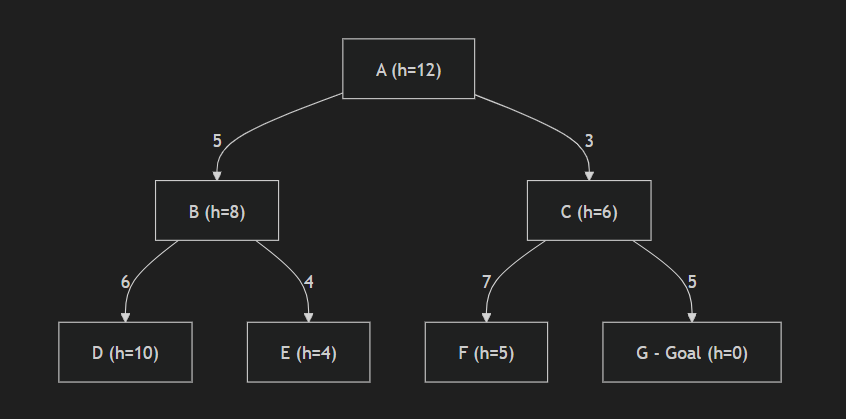

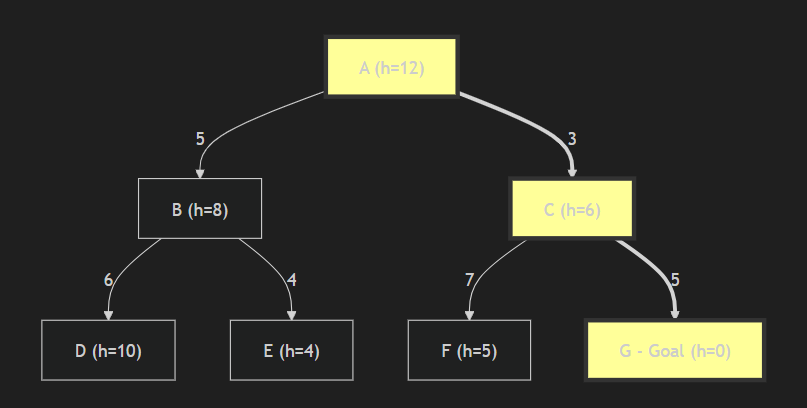

In [1]:
import heapq # Import the heapq module to use a priority queue for the open list

def a_star_algorithm(graph, heuristics, start, goal): # Define the A* function taking graph, heuristics, start, and goal nodes

    # The open_list stores nodes to be explored, format is a tuple: (f_score, current_node)
    open_list = [(heuristics[start], start)] # Initialize open_list with the start node and its initial f_score (which is just its heuristic)

    # g_scores stores the exact, accumulated cost from the start node to any given node
    g_scores = {start: 0} # The cost to get from the start node to itself is always 0

    # came_from keeps track of the optimal path by mapping each node to the parent node we arrived from
    came_from = {} # Initialize an empty dictionary to store this path history

    while open_list: # Continue looping as long as there are unexplored nodes in the open list

        # Pop the node with the lowest f_score from the priority queue
        current_f_score, current_node = heapq.heappop(open_list) # Get the most promising node to explore next

        if current_node == goal: # Check if the node we are currently looking at is our target goal

            # If goal is reached, we need to reconstruct the path tracing backwards
            path = [] # Initialize an empty list to store the final sequence of nodes

            while current_node in came_from: # Loop backwards from the goal until we hit the start node (which has no predecessor)
                path.append(current_node) # Add the current node to our path sequence
                current_node = came_from[current_node] # Move our reference to the parent node we came from

            path.append(start) # Finally, add the start node to the end of the list
            path.reverse() # Reverse the list so the sequence goes chronologically from start to goal

            return path, g_scores[goal] # Return the reconstructed optimal path and the exact total cost to reach the goal

        if current_node in graph: # Ensure the current node actually exists in our graph and has outgoing connections

            for neighbor, weight in graph[current_node].items(): # Iterate over all children of the current node and the edge cost to reach them

                # Calculate the tentative g_score for this specific neighbor
                tentative_g_score = g_scores[current_node] + weight # The cost to get here = cost to parent + cost of the edge between them

                # Check if we have never seen this neighbor before, OR if we just found a faster/cheaper route to it
                if neighbor not in g_scores or tentative_g_score < g_scores[neighbor]:

                    came_from[neighbor] = current_node # Record that the best way to reach this neighbor is from our current node
                    g_scores[neighbor] = tentative_g_score # Update our records with this newly found cheaper exact cost

                    # Calculate the all-important f_score: f(n) = g(n) + h(n)
                    f_score = tentative_g_score + heuristics[neighbor] # Total estimated cost = exact cost so far + estimated cost to finish

                    # Add this neighbor to the open list so it can be evaluated in future loops
                    heapq.heappush(open_list, (f_score, neighbor)) # Push it into the priority queue, sorted by its f_score

    return None, float('inf') # If the while loop finishes and we never hit the return statement inside, no path exists

# --- GRAPH DATA SETUP ---

# Define the tree structure using a dictionary where keys are nodes and values are dictionaries of children and edge weights
graph = { # Start defining the graph dictionary
    'A': {'B': 5, 'C': 3}, # Node A connects to child B (cost 5) and child C (cost 3)
    'B': {'D': 6, 'E': 4}, # Node B connects to child D (cost 6) and child E (cost 4)
    'C': {'F': 7, 'G': 5}, # Node C connects to child F (cost 7) and child G (cost 5)
    'D': {}, # Node D is a leaf node with no children
    'E': {}, # Node E is a leaf node with no children
    'F': {}, # Node F is a leaf node with no children
    'G': {}  # Node G is a leaf node with no children (and is also our intended destination)
} # End defining the graph dictionary

# Define the heuristic (estimated remaining cost) values for each node in the graph
heuristics = { # Start defining the heuristics dictionary
    'A': 12, # An estimated cost of 12 from A to the Goal
    'B': 8,  # An estimated cost of 8 from B to the Goal
    'C': 6,  # An estimated cost of 6 from C to the Goal
    'D': 10, # An estimated cost of 10 from D to the Goal
    'E': 4,  # An estimated cost of 4 from E to the Goal
    'F': 5,  # An estimated cost of 5 from F to the Goal
    'G': 0   # An estimated cost of 0 from G to the Goal (because it IS the goal)
} # End defining the heuristics dictionary

# --- EXECUTION ---

# Call the A* algorithm function we defined, passing in our graph data, heuristics, start point, and end point
optimal_path, total_cost = a_star_algorithm(graph, heuristics, 'A', 'G') # Execute the search algorithm and store the returned tuple

# Print out the final results to the console
print(f"The optimal path is: {' -> '.join(optimal_path)}") # Print the sequence of nodes formatting it nicely with arrows
print(f"The total cost is: {total_cost}") # Print the final calculated actual exact cost to reach the goal


The optimal path is: A -> C -> G
The total cost is: 8
